# Classic models (MIDI) — vodič kroz notebook

Isti zadatak kao u `classic_models_raw.ipynb` — prepoznavanje kompozitora po djelu — ali atributi se ovdje
izvlače iz MusicNet-ovih note-level (MIDI) anotacija (`train_labels/`, `test_labels/`), ne iz audio signala.
Nikakav `.wav` se ne učita, pa je ovaj pipeline mnogo brži od audio verzije.

Isti metodološki okvir: `work_id` grupisanje, `StratifiedGroupKFold`, work-level majority vote, macro F1
kao glavna metrika (dataset je neuravnotežen po kompozitorima).

In [10]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Ucitavanje podataka

## Priprema metapodataka

Pregled izvorne tabele i raspodjele kompozitora nalazi se u [metadata.ipynb](metadata.ipynb).
`load_metadata()` iz `dataset.py` učitava CSV, formira `work_id` kao `composer + " | " + composition`
i zadržava kompozitore sa najmanje `MIN_WORKS_PER_COMPOSER` različitih djela (podrazumijevano 5, iz `config.py`).
Svi stavovi istog djela tako ostaju u istoj grupi tokom evaluacije.

Ova sveska se izvršava samostalno; nije potrebno prethodno pokretati `metadata.ipynb`.

In [11]:
import numpy as np
import pandas as pd

from src.features.dataset import load_metadata
from src.utils.paths import AUDIO_DIR

metadata_filtered = load_metadata()

In [12]:
print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


---

## Group-aware evaluacija

Želimo da mjerimo generalizaciju na **nova djela**, ne na nove segmente poznatog djela. `StratifiedGroupKFold`
drži sve segmente istog `work_id` u istom foldu i približno čuva raspodjelu kompozitora po foldovima.

In [13]:
from sklearn import metrics
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from src.model.evaluation import make_sample_weights, majority_vote_prediction
from src.model.classical_model import run_classical_train_pipeline

sgkf = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

sgkf_outer = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

---

# MIDI model

Svaka nota u MusicNet anotacijama ima visinu, instrument, tačan onset/offset i trajanje u otkucajima.
`extract_midi_features` (u `midi.py`) iz toga računa gustinu nota, melodijski kontur (interval mean/std,
udio uzlaznih/silaznih/ponovljenih koraka), histogram tonskih klasa, histogram instrumenata (11 fiksnih GM
programa u MusicNet-u), on-beat/off-beat omjer i raspon akorada.

Napomena: `end_beat` kolona u MusicNet CSV-u je zapravo **trajanje note u otkucajima**, ne apsolutna
pozicija (provjereno — `end_beat < start_beat` za svaki red u fajlu).

In [14]:
from src.features.midi import make_midi_dataset

X_midi, y_midi, groups_midi = make_midi_dataset(metadata_filtered, AUDIO_DIR)

n_estimators=500, max_depth=20, min_samples_leaf=1: accuracy=0.7693, macro_f1=0.6079
n_estimators=500, max_depth=20, min_samples_leaf=3: accuracy=0.7475, macro_f1=0.6015
n_estimators=500, max_depth=20, min_samples_leaf=5: accuracy=0.7362, macro_f1=0.6004

Best params: {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 1}
Best accuracy: 0.7692687747035574
Best macro F1: 0.6078794013004539
outer fold: best_params={'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 1} -> accuracy=0.8182, macro_f1=0.7406
n_estimators=500, max_depth=20, min_samples_leaf=1: accuracy=0.7678, macro_f1=0.5774
n_estimators=500, max_depth=20, min_samples_leaf=3: accuracy=0.7673, macro_f1=0.6280
n_estimators=500, max_depth=20, min_samples_leaf=5: accuracy=0.7673, macro_f1=0.6736

Best params: {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 5}
Best accuracy: 0.7672924901185771
Best macro F1: 0.6736431019960432
outer fold: best_params={'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf

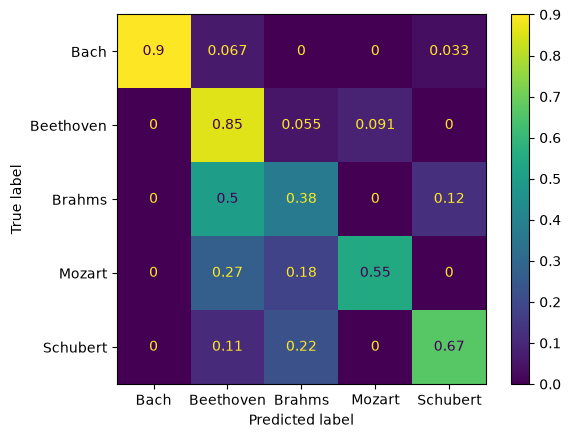

In [15]:
rfc_model = RandomForestClassifier(
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [500], # tried [50, 100, 300] but models statistically improve with more estimators with ceiling at ~500
    "max_depth": [20], # tried 30 as well - but 20 is ceiling here
    "min_samples_leaf": [1, 3, 5] # regularization
}

_ = run_classical_train_pipeline(
    X=X_midi,
    y=y_midi, 
    groups=groups_midi, 
    model=rfc_model, 
    cv=sgkf, 
    param_grid=param_grid, 
    outer_cv=sgkf_outer
)


## ------ SVM Model -------------------------------------- 

In [ ]:
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

param_grid = {
    "C": [10 ** i for i in range(-1, 3)],
    "gamma": [0.001, 0.005, 0.01, 0.1]
}

svm_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel = 'rbf',
        class_weight = None
    )
)

_ = run_classical_train_pipeline(
    X=X_midi,
    y=y_midi, 
    groups=groups_midi, 
    model=svm_model, 
    cv=sgkf, 
    param_grid=param_grid, 
    outer_cv=sgkf_outer
)

---

## XGBoost

Gradient boosting ansambl — stabla se dodaju sekvencijalno, svako ispravlja greške prethodnih. Često
nadmaši Random Forest na ovakvim tabelarnim feature setovima. `LabelEncoder` je potreban jer XGBoost
očekuje numeričke labele, ne stringove.

In [ ]:
from xgboost import XGBClassifier
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

param_grid = {
    "C": [10 ** i for i in range(-1, 3)],
    "gamma": [0.001, 0.005, 0.01, 0.1]
}

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

_ = run_classical_train_pipeline(
    X=X_midi,
    y=y_midi, 
    groups=groups_midi, 
    model=xgb_model, 
    cv=sgkf, 
    label_encode=True
    # param_grid=param_grid, 
    # outer_cv=sgkf_outer
)